# PTA Likelihood vs Pulsar Distance — Realistic Noise

This notebook is a parallel version of `pta_likelihood_vs_distance.ipynb` with
two key differences:

1. **Non-uniform TOA spacing** — each pulsar is observed at random times
   (drawn from a Poisson-like process) rather than evenly spaced.
2. **Realistic noise** — each pulsar includes EFAC, EQUAD, ECORR, and
   power-law red noise in addition to the spindown timing model.

In [1]:
from __future__ import annotations

import logging
import warnings

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
import pint.models as pm
import pint.simulation as psim

from jaxpint import build_timing_model, pint_toas_to_jax
from jaxpint.bridge.model_conversion import pint_model_to_params
from jaxpint.pta.likelihood import PTAConfig, pta_logL
from jaxpint.pta.params import GlobalParams
from jaxpint.pta.signals.cw import CWInjector
from jaxpint.simulation import apply_delay_to_toas

jax.config.update("jax_enable_x64", True)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 10
N_TOAS = 200              # approximate number per pulsar
GLOBAL_START_MJD = 55000.0
GLOBAL_END_MJD = 61000.0  # pulsars drawn from within this window
MIN_SPAN_DAYS = 1500.0    # minimum observation span per pulsar
TOA_ERROR = 1e-8           # 10 ns
FREQ = 1400.0              # MHz
SEED = 42

## Generate random pulsars with realistic noise

Each pulsar has EFAC, EQUAD, ECORR (white/correlated noise) and power-law
red noise (TNRedAmp, TNRedGam, TNRedC).

**Convention:** `CWInjector` reads the `PX` parameter directly as distance in kpc.

In [2]:
rng = np.random.default_rng(SEED)


def random_obs_window(rng):
    """Draw a random start/end MJD within the global window, with minimum span."""
    span = GLOBAL_END_MJD - GLOBAL_START_MJD
    start = rng.uniform(GLOBAL_START_MJD, GLOBAL_END_MJD - MIN_SPAN_DAYS)
    end = rng.uniform(start + MIN_SPAN_DAYS, min(start + span, GLOBAL_END_MJD))
    return start, end


def generate_random_par(idx: int, start_mjd: float, rng: np.random.Generator) -> str:
    """Generate a .par string with spindown + EFAC/EQUAD/ECORR + red noise."""
    # Uniform on the sphere
    ra_hours = rng.uniform(0, 24)
    dec_deg = np.degrees(np.arcsin(rng.uniform(-1, 1)))

    ra_h = int(ra_hours)
    ra_m = int((ra_hours - ra_h) * 60)
    ra_s = (ra_hours - ra_h - ra_m / 60) * 3600

    dec_sign = "+" if dec_deg >= 0 else "-"
    dec_abs = abs(dec_deg)
    dec_d = int(dec_abs)
    dec_m = int((dec_abs - dec_d) * 60)
    dec_s = (dec_abs - dec_d - dec_m / 60) * 3600

    f0 = rng.uniform(100, 500)
    f1 = -10 ** rng.uniform(-16, -14)
    dm = rng.uniform(10, 50)
    px_kpc = rng.uniform(0.5, 3.0)

    # Red noise parameters
    tnredamp = rng.uniform(-15, -12)
    tnredgam = rng.uniform(1.5, 5.0)
    tnredc = 14

    # ECORR in microseconds
    ecorr_us = rng.uniform(0.01, 1.0)

    return f"""\
PSR           J{ra_h:02d}{ra_m:02d}{dec_sign}{dec_d:02d}{dec_m:02d}_{idx:02d}
RAJ           {ra_h:02d}:{ra_m:02d}:{ra_s:08.5f}
DECJ          {dec_sign}{dec_d:02d}:{dec_m:02d}:{dec_s:07.4f}
F0            {f0:.10f}
F1            {f1:.6e}
PEPOCH        {start_mjd:.1f}
DM            {dm:.4f}
PX            {px_kpc:.4f}
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0
EQUAD tel gbt 0.1
ECORR tel gbt {ecorr_us:.4f}
TNRedAmp {tnredamp:.6f}
TNRedGam {tnredgam:.6f}
TNRedC {tnredc}
"""


# Each pulsar gets its own observation window
obs_windows = [random_obs_window(rng) for _ in range(N_PULSARS)]
par_strings = [generate_random_par(i, s, rng) for i, (s, e) in enumerate(obs_windows)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars with individual observation windows:")
for i, (s, e) in enumerate(obs_windows):
    print(f"  Pulsar {i}: MJD {s:.0f} – {e:.0f}  ({(e-s)/365.25:.1f} yr)")
print(f"\nExample .par:\n{par_strings[0]}")

Generated 10 pulsars with individual observation windows:
  Pulsar 0: MJD 58483 – 60429  (5.3 yr)
  Pulsar 1: MJD 58864 – 60807  (5.3 yr)
  Pulsar 2: MJD 55424 – 60901  (15.0 yr)
  Pulsar 3: MJD 58425 – 60770  (6.4 yr)
  Pulsar 4: MJD 55577 – 58844  (8.9 yr)
  Pulsar 5: MJD 56669 – 60793  (11.3 yr)
  Pulsar 6: MJD 57897 – 60716  (7.7 yr)
  Pulsar 7: MJD 56995 – 59065  (5.7 yr)
  Pulsar 8: MJD 57496 – 59124  (4.5 yr)
  Pulsar 9: MJD 58724 – 60714  (5.4 yr)

Example .par:
PSR           J1811-1654_00
RAJ           18:11:38.78074
DECJ          -16:54:53.0055
F0            488.2792097580
F1            -6.112829e-15
PEPOCH        58482.8
DM            41.1353
PX            0.9866
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0
EQUAD tel gbt 0.1
ECORR tel gbt 0.1627
TNRedAmp -13.599837
TNRedGam 1.653313
TNRedC 14



## Generate non-uniform TOAs and convert to JaxPINT

In [3]:
def generate_irregular_mjds(start, end, n_approx, rng):
    """Generate non-uniformly spaced MJDs using a Poisson-like process."""
    avg_gap = (end - start) / n_approx
    mjds = [start]
    while mjds[-1] < end:
        gap = rng.exponential(avg_gap)
        mjds.append(mjds[-1] + gap)
    mjds = np.array(mjds[:-1])
    return mjds[mjds < end]


toa_data_list = []
pulsar_params_list = []
timing_models = []
noise_models = []

for i, model in enumerate(pint_models):
    start_i, end_i = obs_windows[i]
    mjds = generate_irregular_mjds(start_i, end_i, N_TOAS, rng)
    toas = psim.make_fake_toas_fromMJDs(
        mjds, model, obs="GBT", error=TOA_ERROR * u.s, freq=FREQ * u.MHz,
    )
    toa_data = pint_toas_to_jax(toas, model)
    par_result = pint_model_to_params(model)
    tm, nm = build_timing_model(model, toas)

    toa_data_list.append(toa_data)
    pulsar_params_list.append(par_result.params)
    timing_models.append(tm)
    noise_models.append(nm)

    n = len(mjds)
    px_val = float(par_result.params.param_value("PX"))
    print(f"  Pulsar {i}: {model.PSR.value:>20s}  n_toas={n:3d}  MJD {start_i:.0f}–{end_i:.0f}  PX={px_val:.2f} kpc")

print(f"\nAll {N_PULSARS} pulsars loaded.")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 0:        J1811-1654_00  n_toas=213  MJD 58483–60429  PX=0.99 kpc


/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 1:        J1623+2918_01  n_toas=185  MJD 58864–60807  PX=1.67 kpc
  Pulsar 2:        J0526+1951_02  n_toas=186  MJD 55424–60901  PX=1.28 kpc
  Pulsar 3:        J0655+2124_03  n_toas=193  MJD 58425–60770  PX=2.47 kpc
  Pulsar 4:        J1100+0754_04  n_toas=217  MJD 55577–58844  PX=1.68 kpc
  Pulsar 5:        J1317+0648_05  n_toas=196  MJD 56669–60793  PX=1.04 kpc
  Pulsar 6:        J0123-2555_06  n_toas=192  MJD 57897–60716  PX=2.46 kpc
  Pulsar 7:        J0400-7239_07  n_toas=185  MJD 56995–59065  PX=0.90 kpc
  Pulsar 8:        J1042-1345_08  n_toas=192  MJD 57496–59124  PX=0.72 kpc
  Pulsar 9:        J1647-2755_09  n_toas=223  MJD 58724–60714  PX=1.62 kpc

All 10 pulsars loaded.


## Visualize TOA spacing

Show that the TOA cadence is irregular for each pulsar.

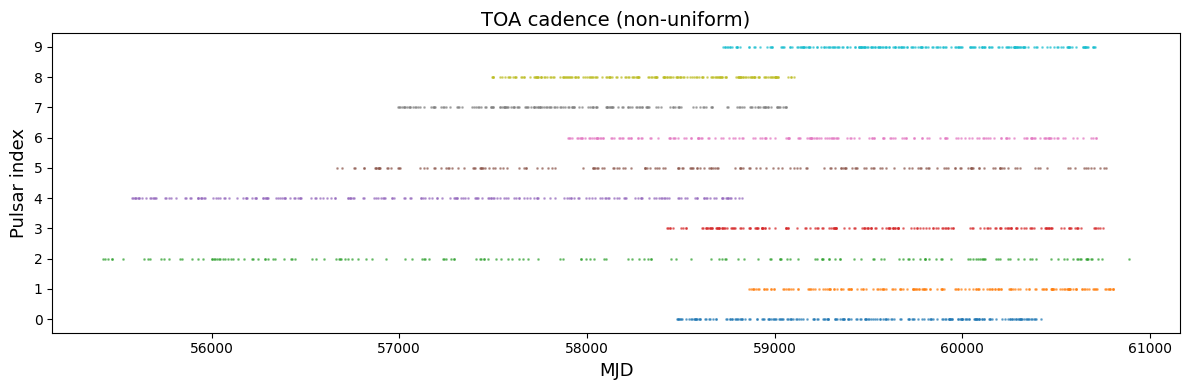

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
for i in range(N_PULSARS):
    mjds = np.array(toa_data_list[i].tdb_int + toa_data_list[i].tdb_frac)
    ax.scatter(mjds, np.full_like(mjds, i), s=1, alpha=0.5)
ax.set_xlabel("MJD", fontsize=13)
ax.set_ylabel("Pulsar index", fontsize=13)
ax.set_title("TOA cadence (non-uniform)", fontsize=14)
ax.set_yticks(range(N_PULSARS))
fig.tight_layout()
plt.show()

## Set up CW sources and PTA config

Same structure as the uniform-cadence notebook: each CW source gets a random
sky position and frequency.

In [5]:
# Compute pulsar unit vectors from RAJ/DECJ
positions = []
for model in pint_models:
    ra_rad = model.RAJ.quantity.to(u.rad).value
    dec_rad = model.DECJ.quantity.to(u.rad).value
    pos = np.array([
        np.cos(dec_rad) * np.cos(ra_rad),
        np.cos(dec_rad) * np.sin(ra_rad),
        np.sin(dec_rad),
    ])
    positions.append(pos)

positions = jnp.array(np.array(positions))

# Each CW source gets a random sky location and GW frequency
all_cw_injectors = []
for m in range(M_CW_SOURCES):
    inj = CWInjector(
        positions,
        prefix=f"cw{m}_",
        initial_values={
            "log10_h": -12.0,
            "cos_gwtheta": rng.uniform(-1, 1),
            "gwphi": rng.uniform(0, 2 * np.pi),
            "log10_fgw": rng.uniform(-9, -7),
        },
    )
    all_cw_injectors.append(inj)

# Save the base (signal-free) TOA data for reuse across M values
base_toa_data_list = list(toa_data_list)
print(f"Generated {M_CW_SOURCES} CW sources")

Generated 10 CW sources


## Sweep distance for pulsar 0

Same as the uniform notebook — sweep PX for the target pulsar across
different numbers of CW sources.

In [6]:
TARGET_PULSAR = 0
true_distance = float(pulsar_params_list[TARGET_PULSAR].param_value("PX"))
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc")

half_window = 0.005  # kpc
distance_grid = np.linspace(
    true_distance - half_window,
    true_distance + half_window,
    500,
)
pp_tuple = tuple(pulsar_params_list)

M_values = [1, 2, 5, M_CW_SOURCES]
results = {}

for M in M_values:
    print(f"\n--- M = {M} CW source(s) ---")
    cw_subset = all_cw_injectors[:M]

    gp = GlobalParams.empty()
    for inj in cw_subset:
        gp = inj.register_params(gp)

    injected_toas = []
    for i in range(N_PULSARS):
        td = base_toa_data_list[i]
        total_delay = jnp.zeros(td.n_toas)
        for inj in cw_subset:
            total_delay += inj.delay(i, td, pulsar_params_list[i], gp)
        injected_toas.append(apply_delay_to_toas(td, total_delay))

    cfg = PTAConfig(
        toa_data_list=tuple(injected_toas),
        timing_models=tuple(timing_models),
        noise_models=tuple(noise_models),
        signal_injectors=tuple(cw_subset),
    )

    @jax.jit
    def _eval(px_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    _ = _eval(jnp.float64(true_distance))
    logL_vals = np.array([float(_eval(jnp.float64(d))) for d in distance_grid])
    results[M] = logL_vals
    print(f"  Sweep complete ({len(distance_grid)} points)")

print("\nAll sweeps done.")

Pulsar 0 true distance: 0.987 kpc

--- M = 1 CW source(s) ---


/tmp/ipykernel_96003/3590756147.py:32: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  cfg = PTAConfig(


  Sweep complete (500 points)

--- M = 2 CW source(s) ---
  Sweep complete (500 points)

--- M = 5 CW source(s) ---
  Sweep complete (500 points)

--- M = 10 CW source(s) ---
  Sweep complete (500 points)

All sweeps done.


## Plot Likelihood

JaxPINT WLS fitter result for pulsar 0:
  PX = 0.986766 +/- 0.009504 kpc (1-sigma)


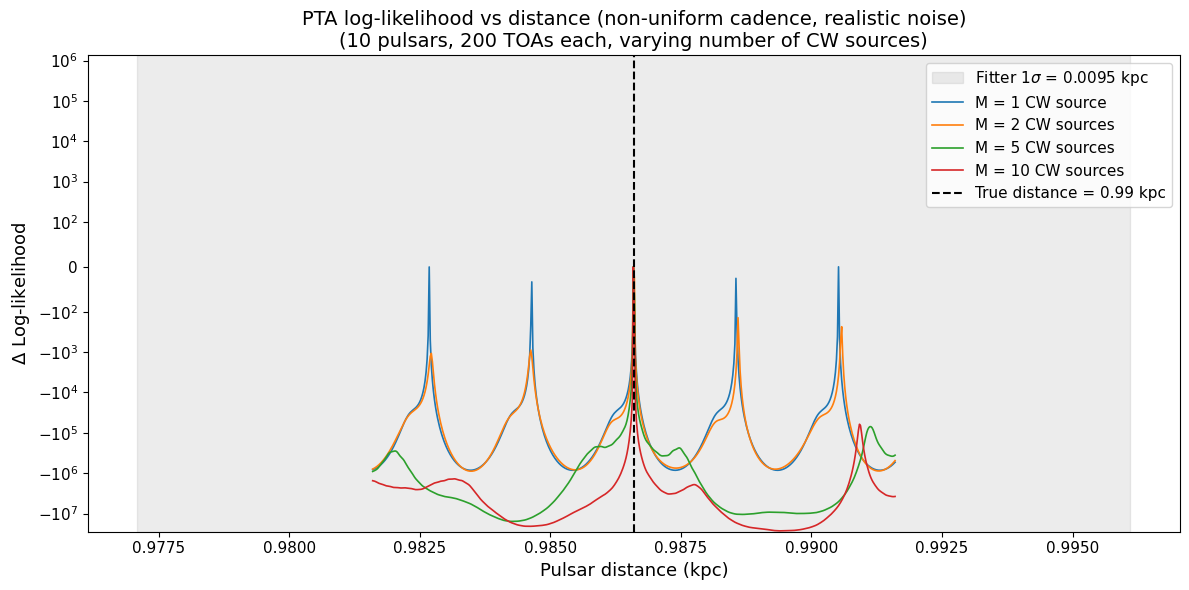

In [7]:
# Fit the target pulsar with JaxPINT's WLS fitter to get PX uncertainty
from jaxpint.fitters import WLSFitter
from jaxpint.types import ParameterVector

target_params = pulsar_params_list[TARGET_PULSAR]
px_idx = target_params.names.index("PX")
new_frozen = list(target_params.frozen_mask)
new_frozen[px_idx] = False
fit_params = ParameterVector(
    values=target_params.values,
    frozen_mask=tuple(new_frozen),
    names=target_params.names,
    units=target_params.units,
    epoch_int_values=target_params.epoch_int_values,
)

fitter = WLSFitter(
    timing_models[TARGET_PULSAR],
    base_toa_data_list[TARGET_PULSAR],
    fit_params,
    noise_models[TARGET_PULSAR],
)
fit_result = fitter.fit_toas()

free_names = [fit_params.names[i] for i in fit_params._free_indices]
px_free_idx = free_names.index("PX")
px_err = float(fit_result.parameter_uncertainties[px_free_idx])

print(f"JaxPINT WLS fitter result for pulsar {TARGET_PULSAR}:")
print(f"  PX = {float(fit_result.params.param_value('PX')):.6f} +/- {px_err:.6f} kpc (1-sigma)")

fig, ax = plt.subplots(figsize=(12, 6))

ax.axvspan(true_distance - px_err, true_distance + px_err,
           alpha=0.15, color="gray", label=f"Fitter 1$\\sigma$ = {px_err:.4f} kpc")

for M in M_values:
    logL = results[M]
    delta_logL = logL - logL.max()
    ax.plot(distance_grid, delta_logL, linewidth=1.2, label=f"M = {M} CW source{'s' if M > 1 else ''}")

ax.axvline(true_distance, color="black", linestyle="--", linewidth=1.5,
           label=f"True distance = {true_distance:.2f} kpc")

ax.set_yscale("symlog", linthresh=1e2)
ax.set_xlabel("Pulsar distance (kpc)", fontsize=13)
ax.set_ylabel("$\\Delta$ Log-likelihood", fontsize=13)
ax.set_title(
    f"PTA log-likelihood vs distance (non-uniform cadence, realistic noise)\n"
    f"({N_PULSARS} pulsars, {N_TOAS} TOAs each, varying number of CW sources)",
    fontsize=14,
)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()